---

# Single Neuron Model: The Perceptron

The Perceptron is a standard single neuron ML model that implements a binary sign activation function for decision-making and prediction.

We will train and test this model on the Iris dataset, introduced by Ronald Fisher and included with scikit-learn. To match the binary perceptron setting, we will focus on distinguishing *setosa* flowers from *versicolor* flowers.

---


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure local package imports work when the notebook runs from any folder.
repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
src_path = repo_root / "src"
if not src_path.exists():
    raise FileNotFoundError(f"Could not find src directory from {Path.cwd()}")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from rice_ml.Supervised_Learning.perceptron_class import Perceptron
from rice_ml.processing.preprocessing import train_test_split, standardize
from rice_ml.processing.postprocessing import PostProcessor

# Import a function for plotting decision boundaries
from mlxtend.plotting import plot_decision_regions

# Set the Seaborn theme
sns.set_theme()

# Reading in the Iris Dataset
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))


In [2]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Dataset Exploration
Fortunately, there are no missing values in the Iris dataset. The measurements for *setosa* and *versicolor* flowers are especially distinct in petal length and petal width, which makes this a useful introductory dataset for binary classification with a perceptron.


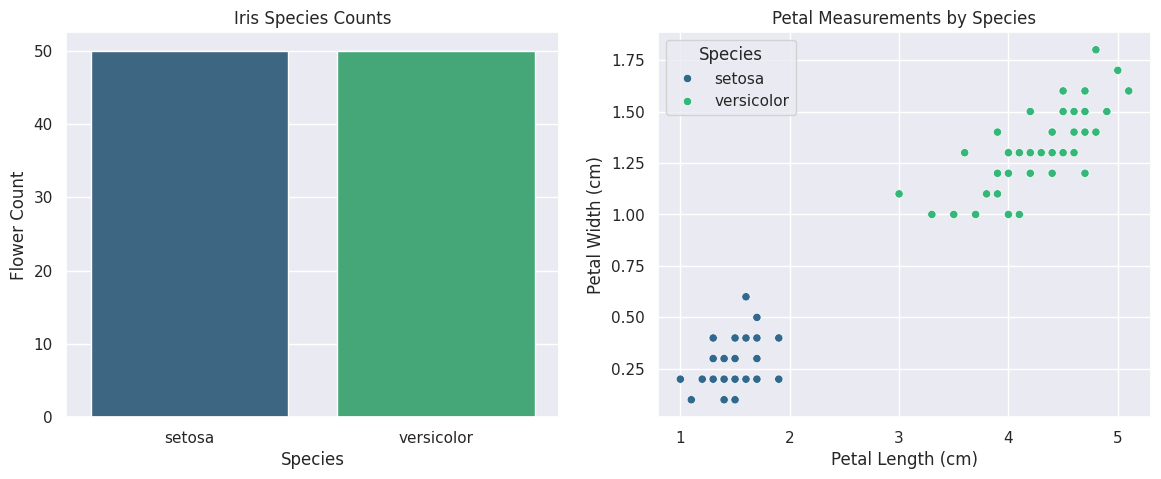

Missing Values per Column:
|                   |   0 |
|:------------------|----:|
| sepal length (cm) |   0 |
| sepal width (cm)  |   0 |
| petal length (cm) |   0 |
| petal width (cm)  |   0 |
| target            |   0 |
| species           |   0 |


In [4]:
binary_df = df[df["species"].isin(["setosa", "versicolor"])].copy()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(binary_df, x="species", hue="species", palette="viridis", legend=False)
plt.title("Iris Species Counts")
plt.xlabel("Species")
plt.ylabel("Flower Count")

plt.subplot(1, 2, 2)
sns.scatterplot(
    binary_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    palette="viridis",
)
plt.title("Petal Measurements by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.show()

print("Missing Values per Column:")
print(binary_df.isnull().sum().to_markdown())


# Preprocessing
No columns need to be dropped for missing values. Since the perceptron implementation is a binary classifier, we will keep only the *setosa* and *versicolor* rows, then encode those species as -1 and 1. The petal measurements are strong predictors and also make the decision boundary easy to visualize in two dimensions.


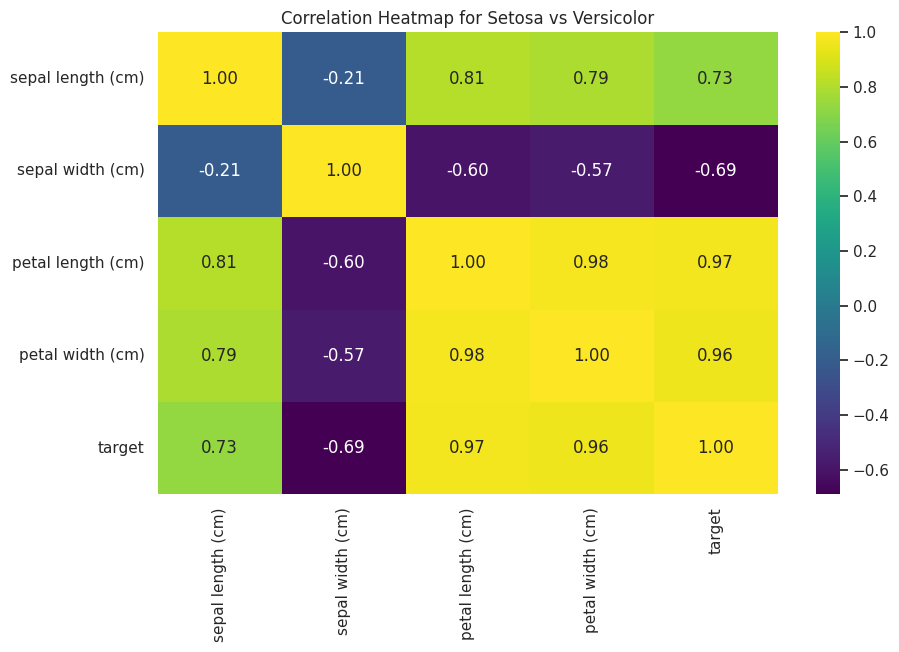

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
selected_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)",
    "target",
]

# Correlation Heatmap of Iris measurements and encoded species target
corr_map = binary_df[selected_features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap for Setosa vs Versicolor")
plt.show()

data = binary_df.copy()
data.head()


---

The perceptron can take in any number of feature measurements, but for simplicity and visualization, we will focus on two highly informative features: petal length and petal width. The following code prepares those features and converts the species labels to -1 and 1.

---


In [6]:
X = data[["petal length (cm)", "petal width (cm)"]].values
y = np.where(data["species"].values == "versicolor", 1, -1)

# Display the first few rows of X and y to confirm
print("First 5 rows of X (features):")
print(X[:5])
print("First 5 values of y (target):")
print(y[:5])


First 5 rows of X (features):
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]
First 5 values of y (target):
[-1 -1 -1 -1 -1]


---

Next we can instantiate an instance of the ```Perceptron``` class and also train this instance over 1000 epochs.

---

In [7]:
# Split data into training and testing sets using the preprocessing module
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features using training-set statistics
X_train, X_test = standardize(X_train, X_test)

# Initialize and train the Perceptron
np.random.seed(42)
perceptron = Perceptron(eta=0.001, epochs=1000)
perceptron.train(X_train, y_train)


---

After training has finished we can call the ```Perceptron``` class ```predict``` method to view its current predictions. We can also visualize the learned linear decision boundary in the two-feature petal measurement space.

---


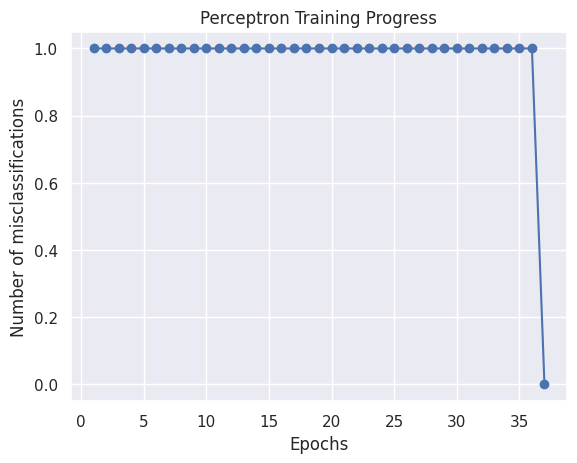

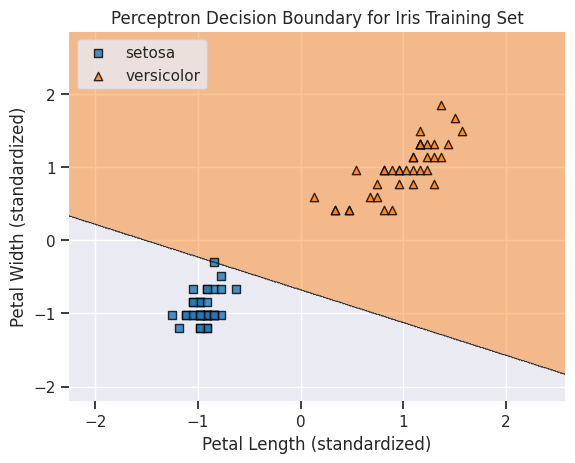

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [8]:
# Plot loss function and decision boundary
perceptron.plot_loss()
plot_decision_regions(X_train, y_train, clf=perceptron)
plt.title("Perceptron Decision Boundary for Iris Training Set")
plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.legend(loc="upper left", labels=["setosa", "versicolor"])
plt.show()

# Predict labels on the test features
y_hat = perceptron.predict(X_test)

# Compare y_hat and y_test
print(y_test == y_hat)


Testing Accuracy: 1.0000
Testing R2 Score: 1.0000
Classification Report:
{'classification_error': 0.0, 'precision': 1.0, 'confusion_matrix': array([[ 9,  0],
       [ 0, 11]])}


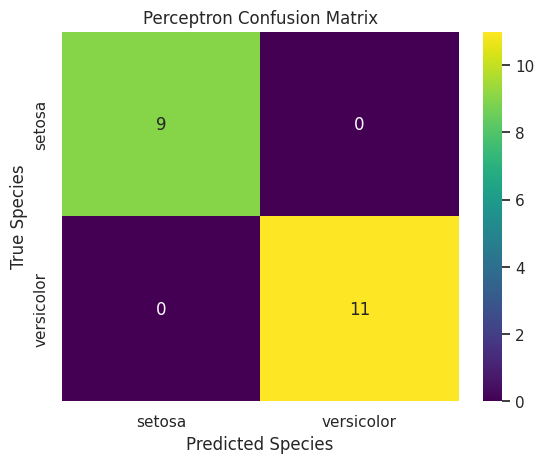

In [9]:
## Classification report and evaluation using PostProcessor 
# Calculate the Perceptron's Accuracy on the Testing Set
processor = PostProcessor()
testing_acc = processor.accuracy(y_test, y_hat)
testing_r2 = processor.r2_score(y_test, y_hat)
print(f"Testing Accuracy: {testing_acc:.4f}")
print(f"Testing R2 Score: {testing_r2:.4f}")

# Classification Metrics Report
class_metrics = processor.classification_metrics(y_test, y_hat, labels=np.array([-1, 1]))
print("Classification Report:")
print(class_metrics)

# Confusion heatmap in seaborn
sns.heatmap(
    class_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["setosa", "versicolor"],
    yticklabels=["setosa", "versicolor"],
)
plt.xlabel("Predicted Species")
plt.ylabel("True Species")
plt.title("Perceptron Confusion Matrix")
plt.show()
